In [105]:
import sys
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

sys.path.insert(0, "/glade/u/home/bbuchovecky/projects/et_controls/binning")
from ppe_2d_binning import _build_edges, _bin_stats_single_member, compute_2d_bin_stats, compute_2d_bin_stats_single_member

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='15GB',
    walltime='02:00:00',
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  15GB
walltime: 02:00:00


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38535 instead
  warnings.warn(


{'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 38535:128.117.211.161:38535 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:38535/status


In [186]:
xclim.close_dask_cluster(client_cluster)

In [30]:
tperiod = slice('1995-01', '2014-12')
grid = xclim.load_fhist_ppe_grid().compute()

In [31]:
snow_pct_threshold = 80 / 100  # maximum allowable percent of snow cover on all months of the average year
nonglc_pct_threshold = 80      # maximum allowable percent of glaciated land for a NON-glaciated gridcell
time_slice = slice("1995-01", "2014-12")

z_var = "ET"
x_var = "AI"
y_var = "TLAI"

variable_names = [
    "FSNO",
    "EFLX_LH_TOT", "TLAI",
    "FLDS", "FIRE", "FIRA",
    "FSDS", "FSR", "FSA",
    "PRECC", "PRECL",
]

# Load variables
fhist = {}
variables = []
for v in variable_names:
    print(v)
    key = f"{v}_month_1"
    fhist[key] = (
        xclim.load_fhist(key, keep_var_only=True)[v]
        .sel(time=time_slice)
        .reindex_like(grid, method="nearest", tolerance=1e-3)
        .chunk({'time': -1})
        .persist()
    )
    variables.append(key)

# Rename ET
fhist["ET_month_1"] = fhist["EFLX_LH_TOT_month_1"]
fhist.pop("EFLX_LH_TOT_month_1")

# Monthly net radiation at the surface, + down
#   Rn = (net SW) + (net LW) = (down SW - up SW) - (down LW - up LW)
#   Rn = FSDS - FSR + FLDS - FIRE
fhist["RN_month_1"] = fhist["FSDS_month_1"] - fhist["FSR_month_1"] + fhist["FLDS_month_1"] - fhist["FIRE_month_1"]
fhist["RN_month_1"] = fhist["RN_month_1"].rename("RN")
fhist["RN_month_1"].attrs = {
    "long_name": "net radiation at surface [+ down]",
    "description": "FSDS - FSR + FLDS - FIRE",
    "units": "W/m2",
}

# Climatological net radiation at the surface
fhist["RN_clim"] = fhist["RN_month_1"].weighted(fhist["RN_month_1"].time.dt.days_in_month).mean("time")
fhist["RN_clim"].attrs["time_mean"] = f"{time_slice.start} to {time_slice.stop}"

# Monthly precipitation rate (PRECC + PRECL)
fhist["PRECT_month_1"] = (fhist["PRECC_month_1"] + fhist["PRECL_month_1"]) * 1000 * 2.5e6
fhist["PRECT_month_1"] = xr.where(fhist["PRECT_month_1"] < 1e-3, 1e-3, fhist["PRECT_month_1"])
fhist["PRECT_month_1"].attrs["units"] = "W/m2"

# Climatological precipitation rate
fhist["PRECT_clim"] = fhist["PRECT_month_1"].weighted(fhist["PRECT_month_1"].time.dt.days_in_month).mean("time")
fhist["PRECT_clim"].attrs["time_mean"] = f"{time_slice.start} to {time_slice.stop}"

# Climatological Aridity Index (AI = RN / PRECT)
fhist["AI_clim"] = fhist["RN_clim"] / fhist["PRECT_clim"]
fhist["AI_clim"] = fhist["AI_clim"].rename("AI")
fhist["AI_clim"].attrs = {
    "long_name": "aridity index",
    "description": "Rn / (Lv * P)",
    "time_mean": f"{time_slice.start} to {time_slice.stop}"
}

# Create masks
fhist["FSNO_clim"] = fhist["FSNO_month_1"].weighted(fhist["FSNO_month_1"].time.dt.days_in_month).mean("time")
snow_mask = xr.where(fhist["FSNO_clim"] > snow_pct_threshold, 0, 1)
nonglc_mask = grid.PCT_GLC < nonglc_pct_threshold

FSNO
EFLX_LH_TOT
TLAI
FLDS
FIRE
FIRA
FSDS
FSR
FSA
PRECC
PRECL


In [10]:
fhist["AI_clim"].isel(member=0)

<xarray.DataArray 'AI' (lat: 96, lon: 144)> Size: 111kB
dask.array<getitem, shape=(96, 144), dtype=float64, chunksize=(96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    member   int64 8B 0
Attributes:
    long_name:    aridity index
    description:  Rn / (Lv * P)
    time_mean:    1995-01 to 2014-12

In [16]:
n_x_bins = 15
x_strategy = 'quantile'
x_range = None

x_da = fhist["AI_clim"].where(nonglc_mask).sel(member=0)

# dim_order = tuple(d for d in x_da.dims if d != "member") + ("member",)
# x_da = x_da.transpose(*dim_order)

# Materialise once; tolerated for PPE sizes (typically <10 GB per variable)
def _np(da):
    return da.compute().values if hasattr(da.data, "compute") else da.values

x_np = _np(x_da)

In [35]:
x_edges = _build_edges(x_np.ravel(), n_x_bins, x_strategy, x_range)
x_edges_xr = x_da.stack(z=['lat', 'lon']).quantile(np.linspace(0.0, 1.0, n_x_bins + 1), dim='z', skipna=True).compute()

In [41]:
x_bins = np.clip(np.searchsorted(x_edges, x_np.flatten(), side="right") - 1, 0, n_x_bins - 1).reshape(x_da.shape)
x_bins_xr = xclim.binned.get_bins(x_da, x_edges_xr, dim='quantile').compute()

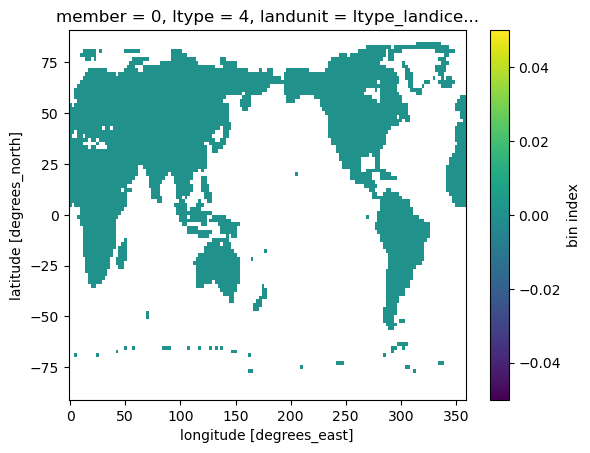

In [37]:
(xr.DataArray(
    data=x_bins,
    coords=dict(
        lat=x_da.lat,
        lon=x_da.lon,
    )
).where(np.isfinite(x_da)) - x_bins_xr).plot(robust=True)

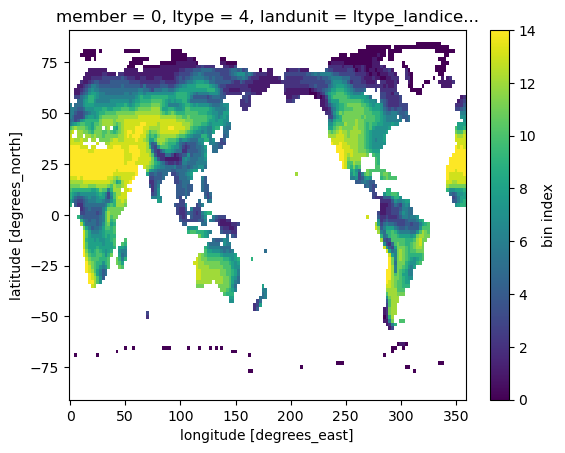

In [42]:
x_bins_xr.plot()

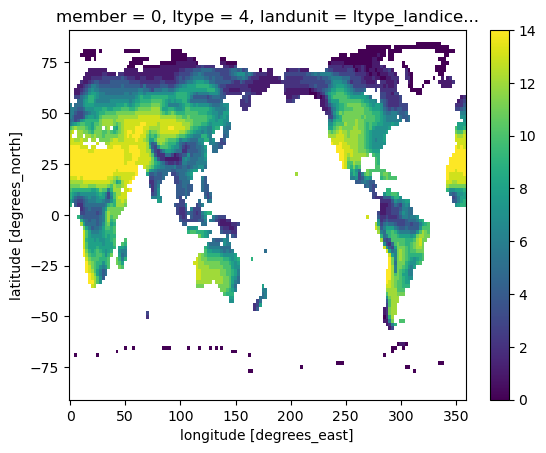

In [43]:
(xr.DataArray(
    data=x_bins,
    coords=dict(
        lat=x_da.lat,
        lon=x_da.lon,
    )
).where(np.isfinite(x_da))).plot()

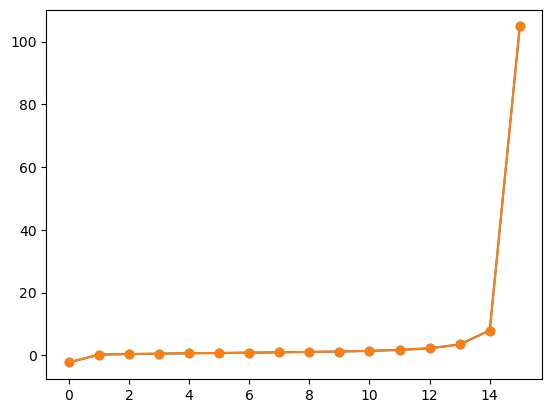

In [44]:
plt.plot(np.arange(n_x_bins + 1), x_edges, marker='o')
plt.plot(np.arange(n_x_bins + 1), x_edges, marker='o')

In [161]:
member = 15

lai = fhist['TLAI_month_1']

target = fhist['ET_month_1'] - fhist['ET_month_1'].sel(member=0)
x_var = fhist['AI_clim']
y_var = lai

target = target.where(nonglc_mask)
x_var = x_var.where(nonglc_mask)
y_var = y_var.where(nonglc_mask)

# Stack x_var to have the same time dimension as y_var by repeating
x_var = x_var.expand_dims(time=y_var.time)

bin_stats = compute_2d_bin_stats(target, y_var, x_var, member_dim='member', collapse_duplicate_quantile_bins=False)

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 1.33 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [162]:
member = 15

lai = fhist['TLAI_month_1']

target = fhist['ET_month_1'] - fhist['ET_month_1'].sel(member=0)
x_var = fhist['AI_clim']
y_var = lai

target = target.where(lai.min(dim='time') > 0).where(nonglc_mask)
x_var = x_var.where(lai.min(dim='time') > 0).where(nonglc_mask)
y_var = y_var.where(lai.min(dim='time') > 0).where(nonglc_mask)

# Stack x_var to have the same time dimension as y_var by repeating
x_var = x_var.expand_dims(time=y_var.time)

bin_stats_lai_gr_0 = compute_2d_bin_stats(target, y_var, x_var, member_dim='member', collapse_duplicate_quantile_bins=False)

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 1.33 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [149]:
member = 15

lai = fhist['TLAI_month_1'].sel(member=member)

target = fhist['ET_month_1'].sel(member=member) - fhist['ET_month_1'].sel(member=0)
x_var = fhist['AI_clim'].sel(member=member)
y_var = lai

target = target.where(nonglc_mask)
x_var = x_var.where(nonglc_mask)
y_var = y_var.where(nonglc_mask)

# Stack x_var to have the same time dimension as y_var by repeating
x_var = x_var.expand_dims(time=y_var.time)

bin_stats_mem15 = compute_2d_bin_stats_single_member(target, y_var, x_var, collapse_duplicate_quantile_bins=False)

In [150]:
member = 15

lai = fhist['TLAI_month_1'].sel(member=member)

target = fhist['ET_month_1'].sel(member=member) - fhist['ET_month_1'].sel(member=0)
x_var = fhist['AI_clim'].sel(member=member)
y_var = lai

target = target.where(lai.min(dim='time') > 0).where(nonglc_mask)
x_var = x_var.where(lai.min(dim='time') > 0).where(nonglc_mask)
y_var = y_var.where(lai.min(dim='time') > 0).where(nonglc_mask)

# Stack x_var to have the same time dimension as y_var by repeating
x_var = x_var.expand_dims(time=y_var.time)

bin_stats_lai_gr_0_mem15 = compute_2d_bin_stats_single_member(target, y_var, x_var, collapse_duplicate_quantile_bins=False)

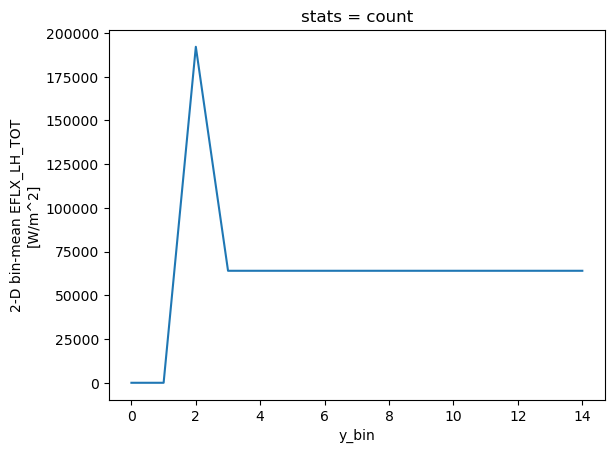

In [151]:
bin_stats_mem15.sel(stats='count').sum(dim='x_bin').plot()

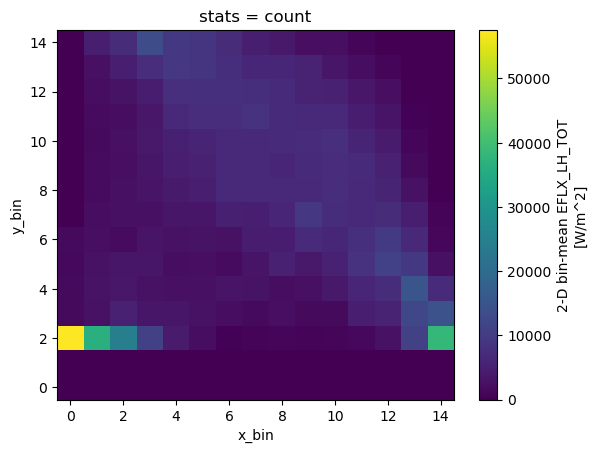

In [152]:
bin_stats_mem15.sel(stats='count').plot()

In [187]:
bin_stats_mem15

<xarray.DataArray (stats: 4, y_bin: 15, x_bin: 15)> Size: 7kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [ 1.13725335e-02, -9.08781275e-02, -2.54162078e-03,
          1.18526197e-01,  1.73999021e-01, -8.27148045e-02,
          1.12727875e+00,  7.30784494e-01,  8.04516854e-01,
         -1.26204823e+00, -1.22932001e+00, -2.24952844e+00,
         -2.70178296e+00, -1.21943908e+00, -6.37627708e-01],
        [-3.04985352e-02,  1.00757676e-01, -1.97033648e-01,
         -2.65012148e-01, -4.23335323e-01, -1.16259972e-01,
          8.59293980e-02, -4.78058920e-01, -8.03632343e-01,
         -5.84378769e-01, -4.95018542e-01, -1.20005236e+00,
         -1.85958677e+00, -1.15524802e+00,  2.62986595e-02],
...
        [ 8.00000000e+00,  1.75000000e+03,  1.85300000e+03,
          3.51000000e+03,  6.46100000e+03,  7.36900000e+03,
          7.36600000e+03,  8.28500000e+03,  6.93200000e+03,
          6.43500000e+03,  6.30400000e+03,  4.31000000e+03,
          3.13800000e+03,  3.00000000e+02,  1.10000000e+01],
        [ 1.33000000e+02,  1.86200000e+03,  2.69900000e+03,
          4.69600000e+03,  7.68800000e+03,  7.95600000e+03,
          7.93800000e+03,  7.62100000e+03,  6.96500000e+03,
          5.52400000e+03,  5.25800000e+03,  3.41200000e+03,
          2.20100000e+03,  7.90000000e+01,  0.00000000e+00],
        [ 0.00000000e+00,  2.25100000e+03,  4.78600000e+03,
          7.37300000e+03,  9.19300000e+03,  8.89300000e+03,
          7.60600000e+03,  6.20000000e+03,  6.17200000e+03,
          5.46100000e+03,  3.33300000e+03,  1.94000000e+03,
          8.07000000e+02,  1.70000000e+01,  0.00000000e+00],
        [ 0.00000000e+00,  4.86000000e+03,  6.97800000e+03,
          1.32070000e+04,  9.42000000e+03,  8.98400000e+03,
          7.02000000e+03,  4.74300000e+03,  3.76300000e+03,
          2.22000000e+03,  2.05100000e+03,  6.91000000e+02,
          9.20000000e+01,  3.00000000e+00,  0.00000000e+00]]])
Coordinates:
  * stats            (stats) <U8 128B 'mean' 'var_pop' 'var_samp' 'count'
    TLAI_bin_center  (y_bin) float64 120B 0.0 0.0 0.0002155 ... 3.131 5.784
    TLAI_bin_label   (y_bin) <U8 480B 'Q0-Q7' 'Q7-Q13' ... 'Q87-Q93' 'Q93-Q100'
    AI_bin_center    (x_bin) float64 120B -0.9099 0.3115 0.4563 ... 5.566 74.33
    AI_bin_label     (x_bin) <U8 480B 'Q0-Q7' 'Q7-Q13' ... 'Q87-Q93' 'Q93-Q100'
Dimensions without coordinates: y_bin, x_bin
Attributes: (12/13)
    long_name:                         2-D bin-mean EFLX_LH_TOT
    units:                             W/m^2
    y_variable:                        TLAI
    x_variable:                        AI
    y_strategy:                        quantile
    x_strategy:                        quantile
    ...                                ...
    x_bin_edges:                       [-2.0546579403330036, 0.23490894191323...
    n_y_bins:                          15
    n_x_bins:                          15
    n_y_bins_requested:                15
    n_x_bins_requested:                15
    collapse_duplicate_quantile_bins:  False

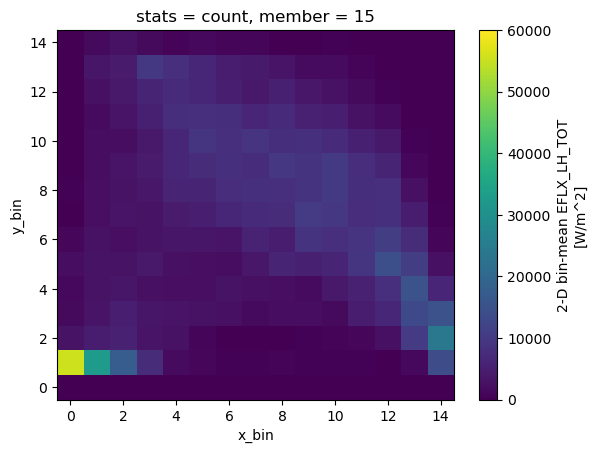

In [163]:
bin_stats.sel(stats='count', member=15).plot(vmin=0, vmax=60000)

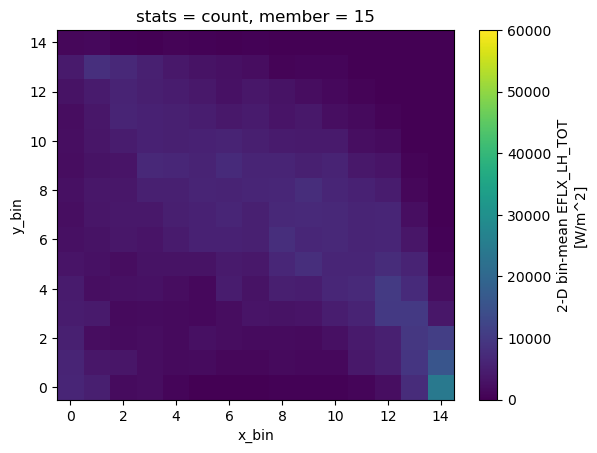

In [164]:
bin_stats_lai_gr_0.sel(stats='count', member=15).plot(vmin=0, vmax=60000)

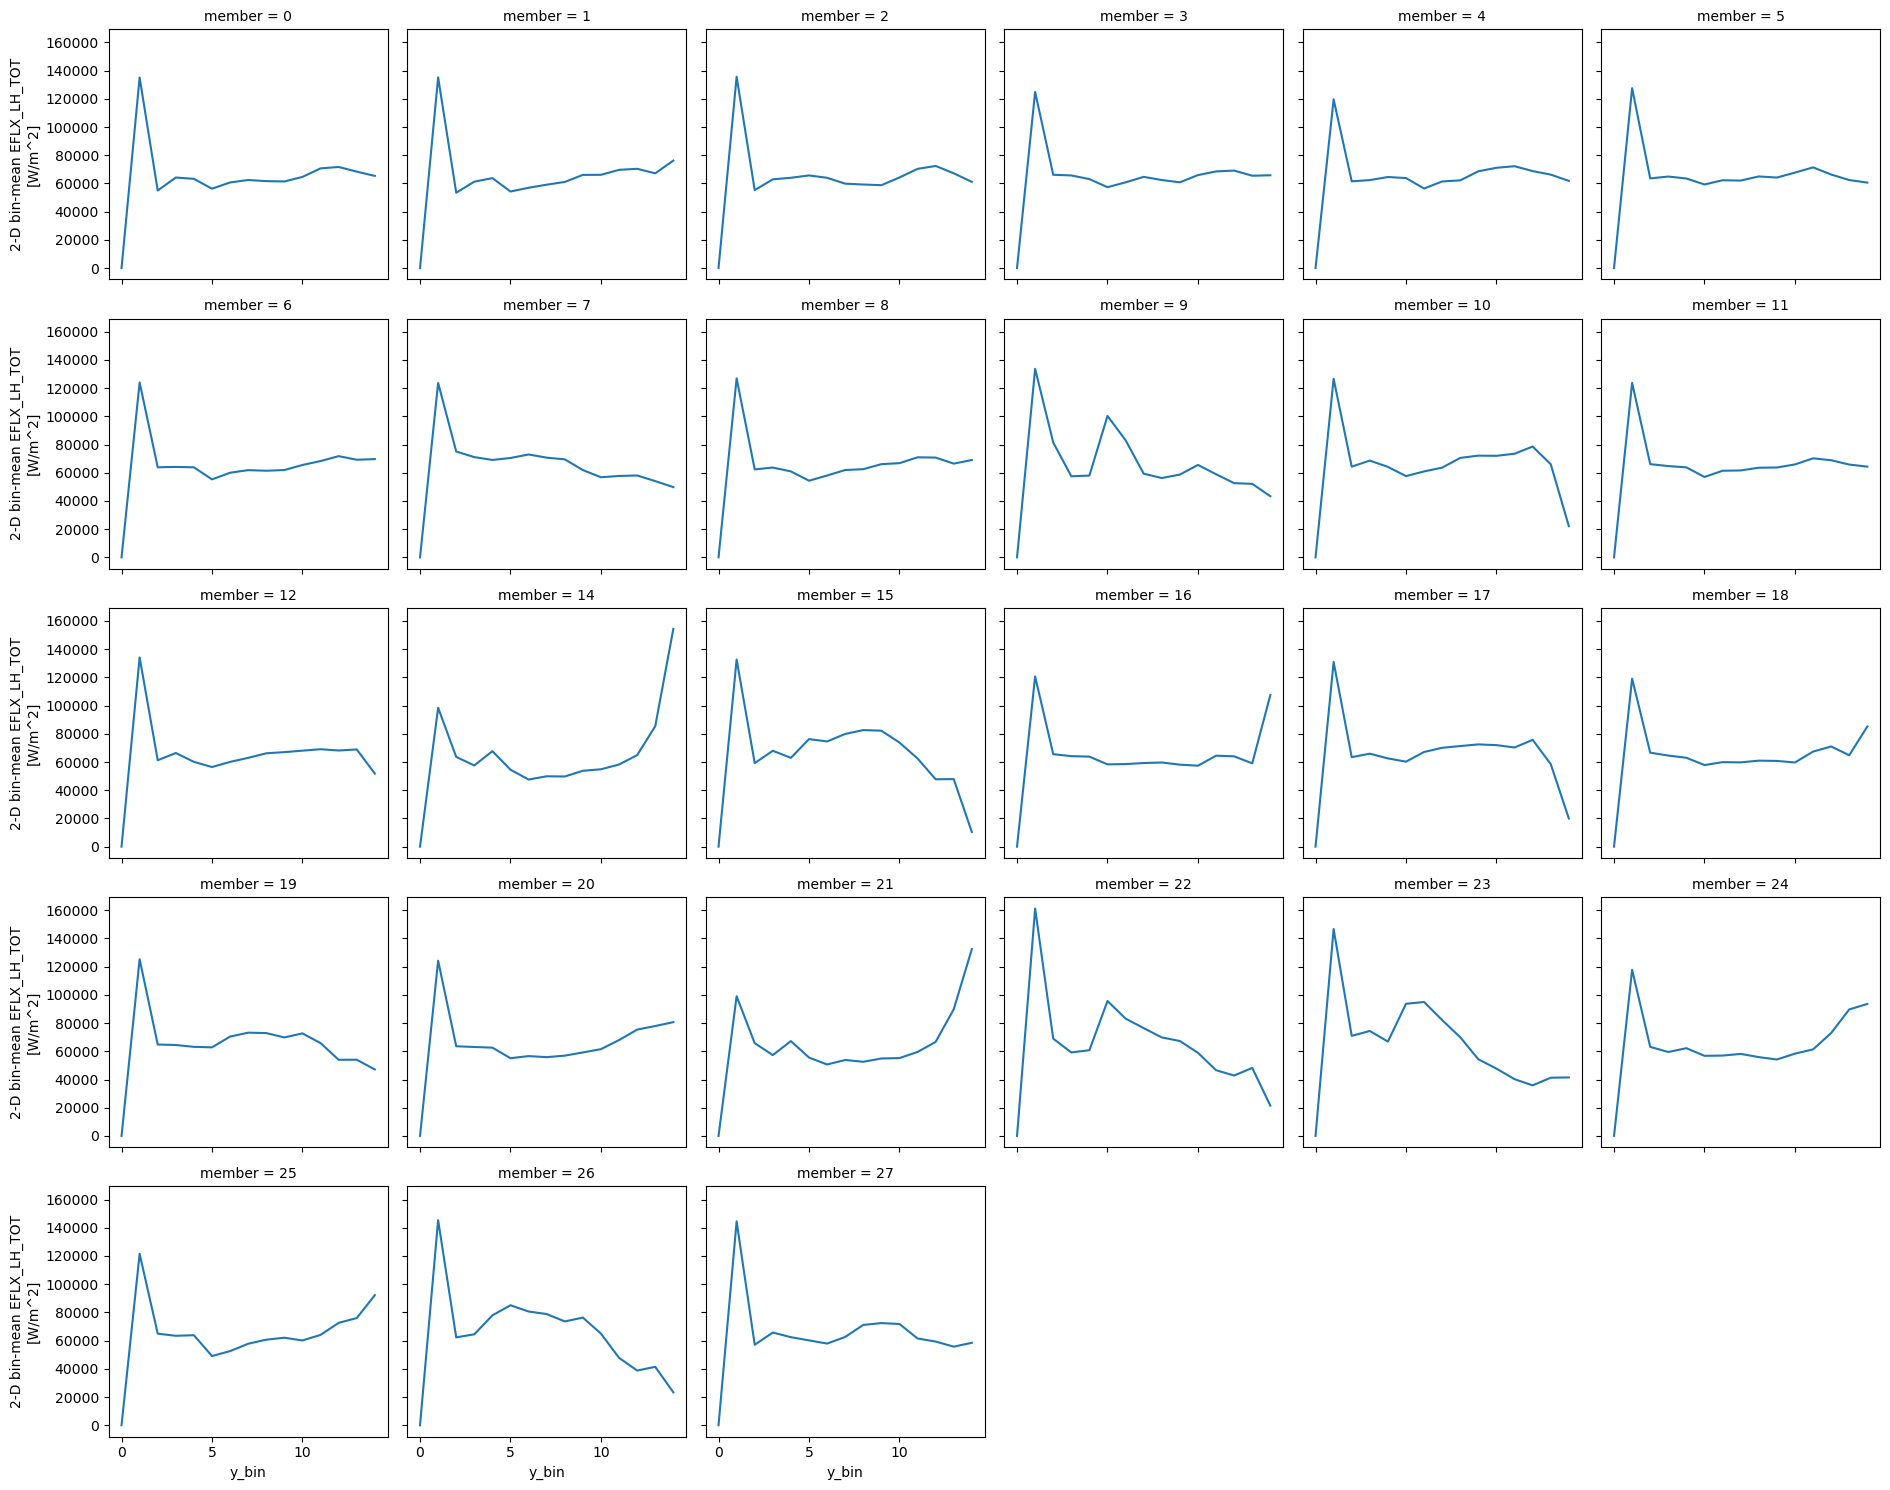

In [165]:
bin_stats.sel(stats='count').sum(dim='x_bin').plot(col='member', col_wrap=6)

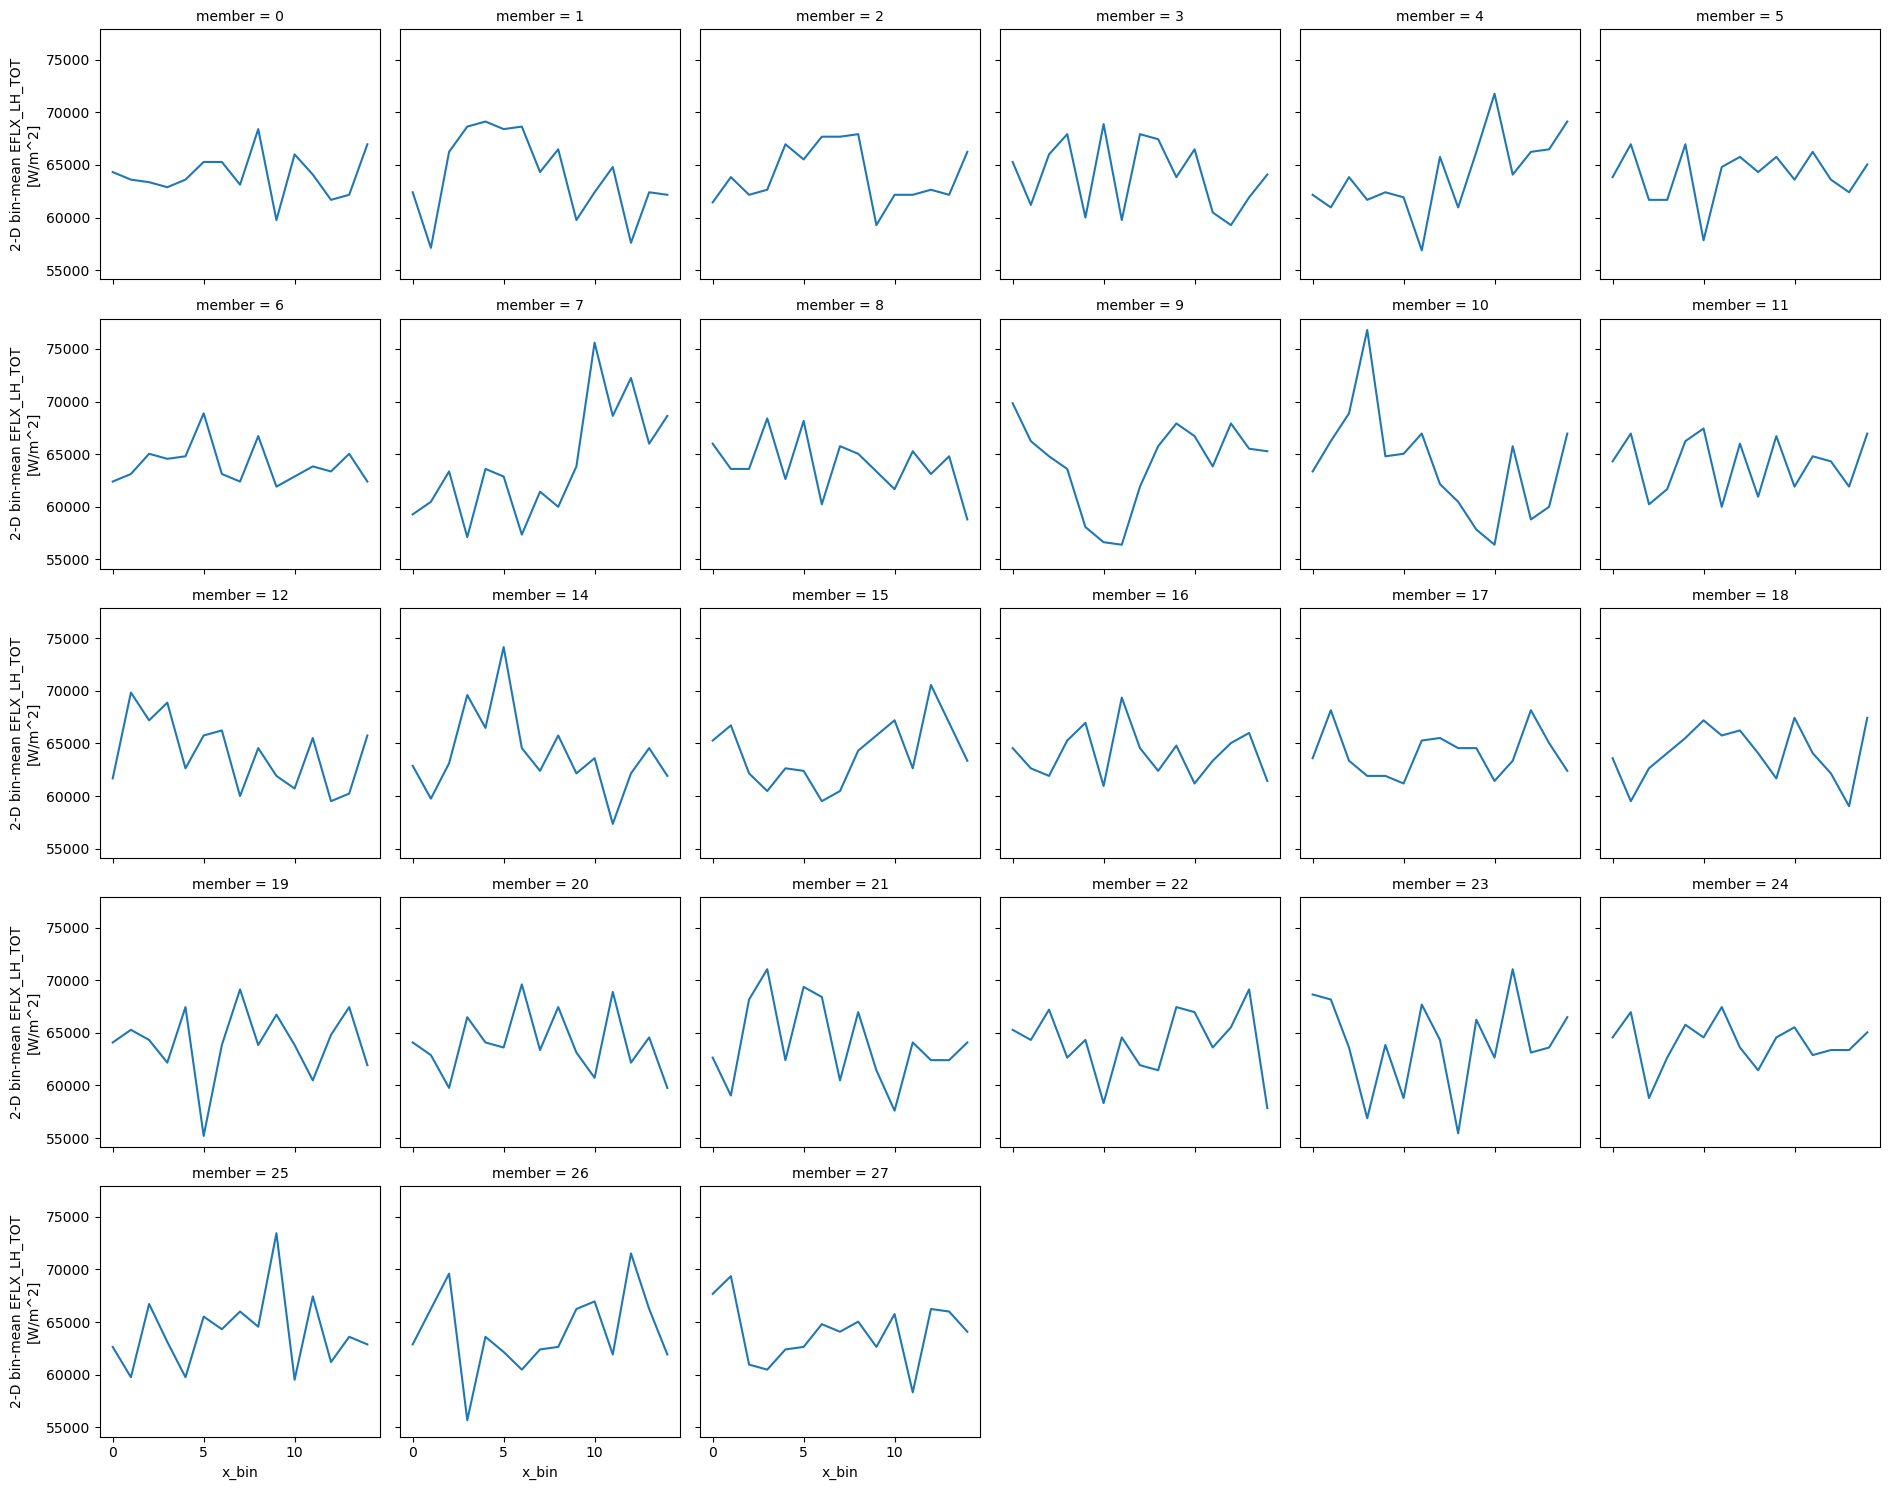

In [169]:
bin_stats.sel(stats='count').sum(dim='y_bin').plot(col='member', col_wrap=6)

In [178]:
bin_stats

<xarray.DataArray (stats: 4, y_bin: 15, x_bin: 15, member: 27)> Size: 194kB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[ 0.00000000e+00, -1.07681898e-02, -2.86798152e-02, ...,
           1.96707950e-02, -1.06296084e-02, -9.28155228e-02],
         [ 0.00000000e+00,  2.58284692e-01, -6.72352765e-03, ...,
           1.28349273e-01, -2.15301207e-01, -2.78481001e-01],
         [ 0.00000000e+00,  2.98471937e-01, -1.53369437e-02, ...,
           2.29295935e-01, -2.09617686e-01, -3.32012940e-01],
...
           3.06000000e+02,  1.68000000e+02,  1.36000000e+02],
         [ 1.00000000e+00,  0.00000000e+00,  3.00000000e+00, ...,
           4.00000000e+00,  0.00000000e+00,  1.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 3.87400000e+03,  2.66500000e+03,  4.50400000e+03, ...,
           2.89300000e+03,  1.94400000e+03,  3.98600000e+03],
         [ 7.44600000e+03,  9.43400000e+03,  6.33400000e+03, ...,
           1.03600000e+04,  4.56600000e+03,  7.32700000e+03],
         ...,
         [ 1.60000000e+01,  4.00000000e+01,  8.50000000e+01, ...,
           8.00000000e+01,  4.20000000e+01,  3.60000000e+01],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]]],
      shape=(4, 15, 15, 27))
Coordinates:
  * stats            (stats) <U8 128B 'mean' 'var_pop' 'var_samp' 'count'
    TLAI_bin_center  (y_bin) float64 120B 0.0 2.377e-12 ... 4.232 10.56
    TLAI_bin_label   (y_bin) <U8 480B 'Q0-Q7' 'Q7-Q13' ... 'Q87-Q93' 'Q93-Q100'
    AI_bin_center    (x_bin) float64 120B -1.103 0.3166 0.4607 ... 5.556 74.34
    AI_bin_label     (x_bin) <U8 480B 'Q0-Q7' 'Q7-Q13' ... 'Q87-Q93' 'Q93-Q100'
  * member           (member) int64 216B 0 1 2 3 4 5 6 ... 21 22 23 24 25 26 27
Dimensions without coordinates: y_bin, x_bin
Attributes: (12/14)
    long_name:                         2-D bin-mean EFLX_LH_TOT
    units:                             W/m^2
    y_variable:                        TLAI
    x_variable:                        AI
    y_strategy:                        quantile
    x_strategy:                        quantile
    ...                                ...
    n_y_bins:                          15
    n_x_bins:                          15
    n_y_bins_requested:                15
    n_x_bins_requested:                15
    collapse_duplicate_quantile_bins:  False
    pool_edges:                        True

In [181]:
import scipy.stats as stats

alpha = 0.05
n_min = 0

means = bin_stats.sel(stats='mean')
stds = np.sqrt(bin_stats.sel(stats='var_samp'))
ns = bin_stats.sel(stats='count')

# Calculate t-statistic and critical value
t_critical = stats.t.ppf(1 - alpha / 2, ns - 1)
t_statistic = means / (stds / np.sqrt(ns))

# Perform significance test
significant = (np.abs(t_statistic) > t_critical) & (bin_stats.sel(stats='count') > n_min)

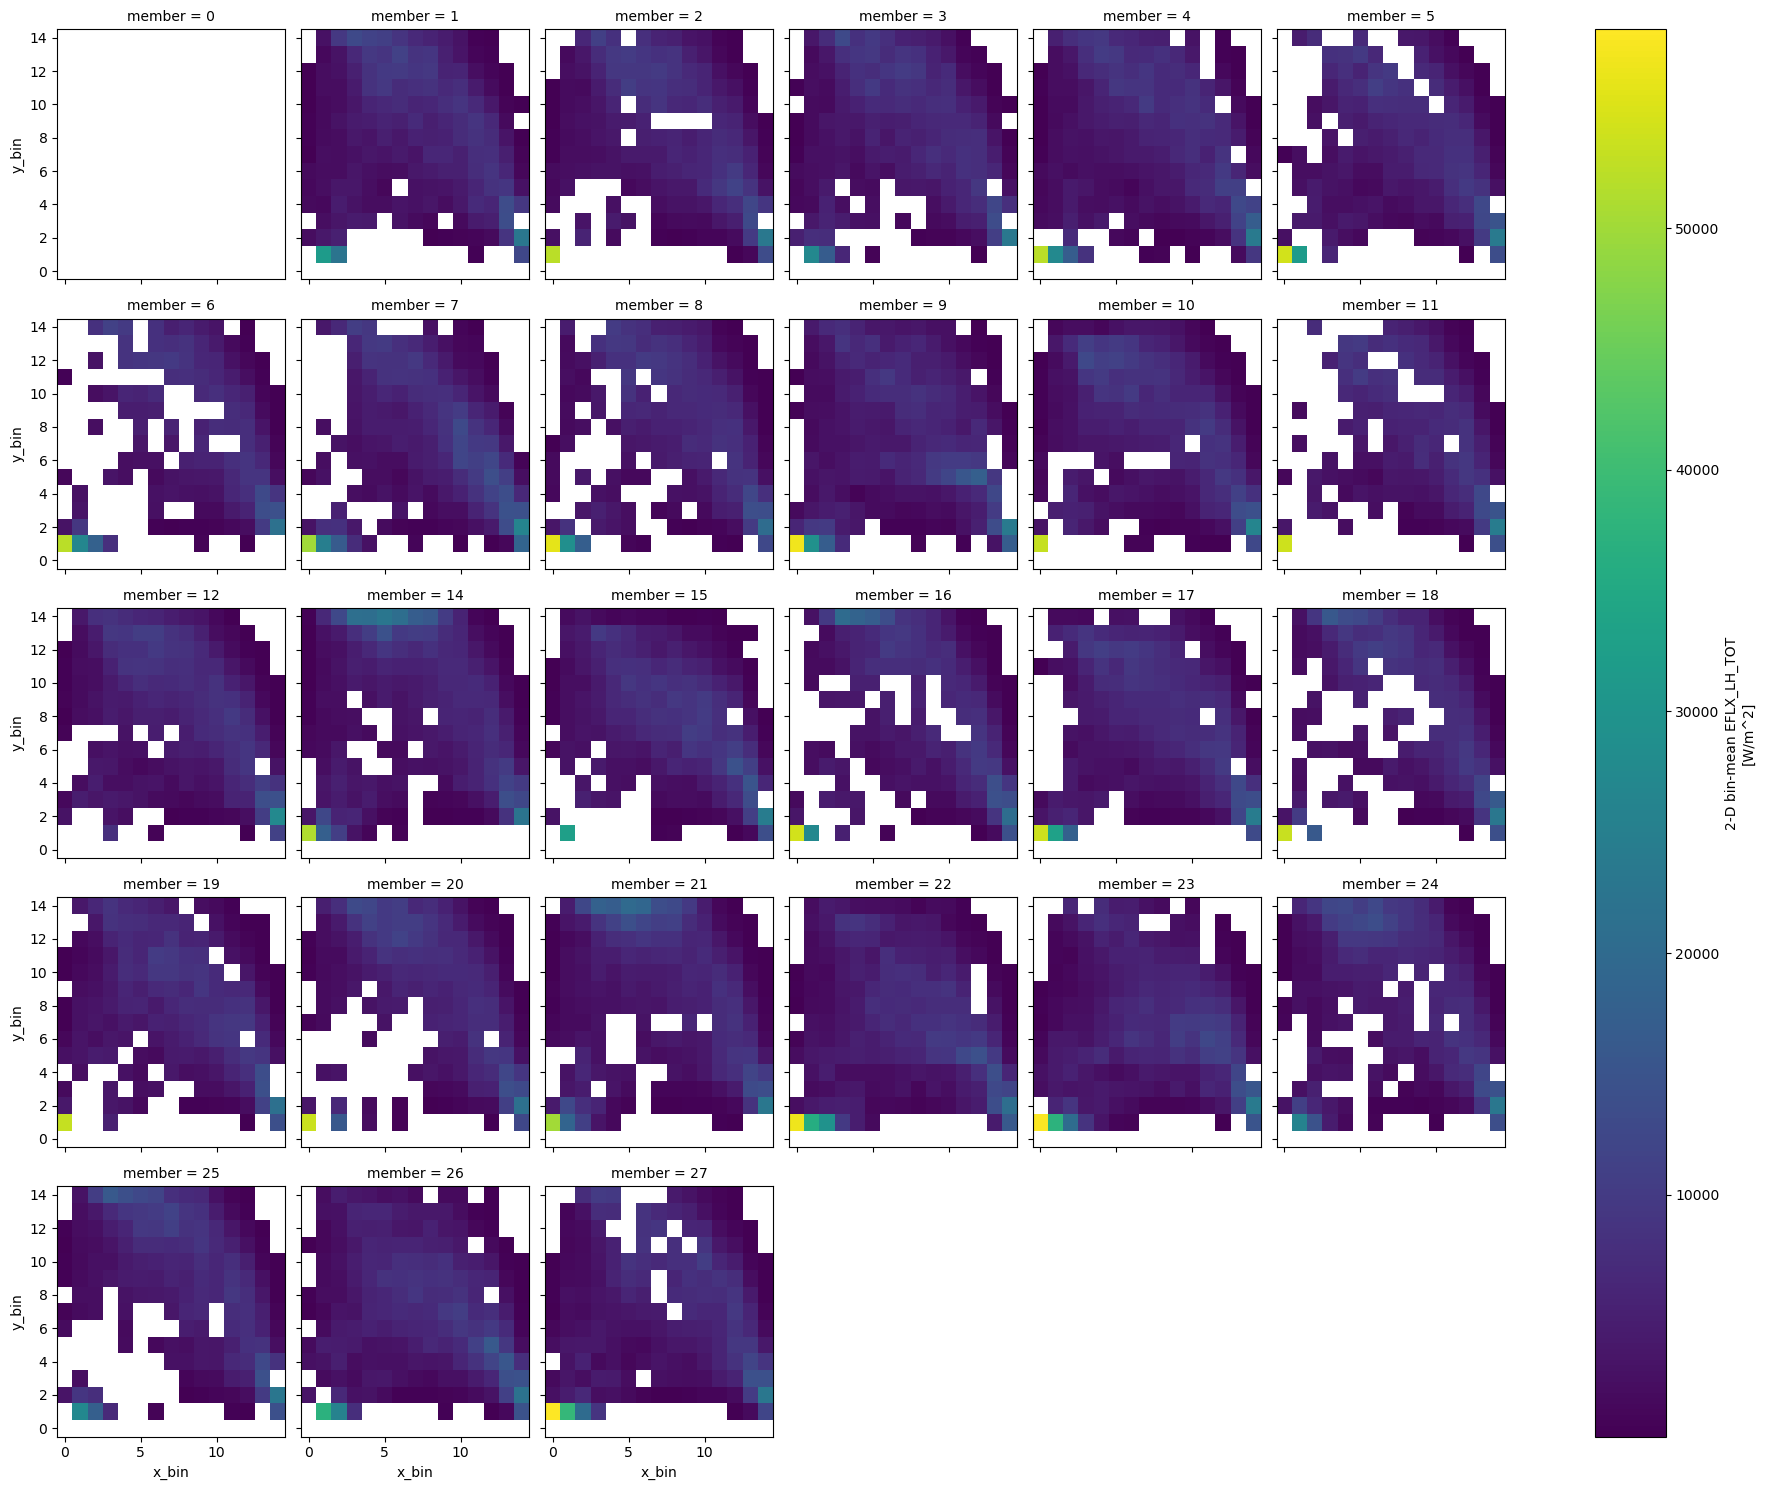

In [182]:
bin_stats.sel(stats='count').where(significant).plot(col='member', col_wrap=6)

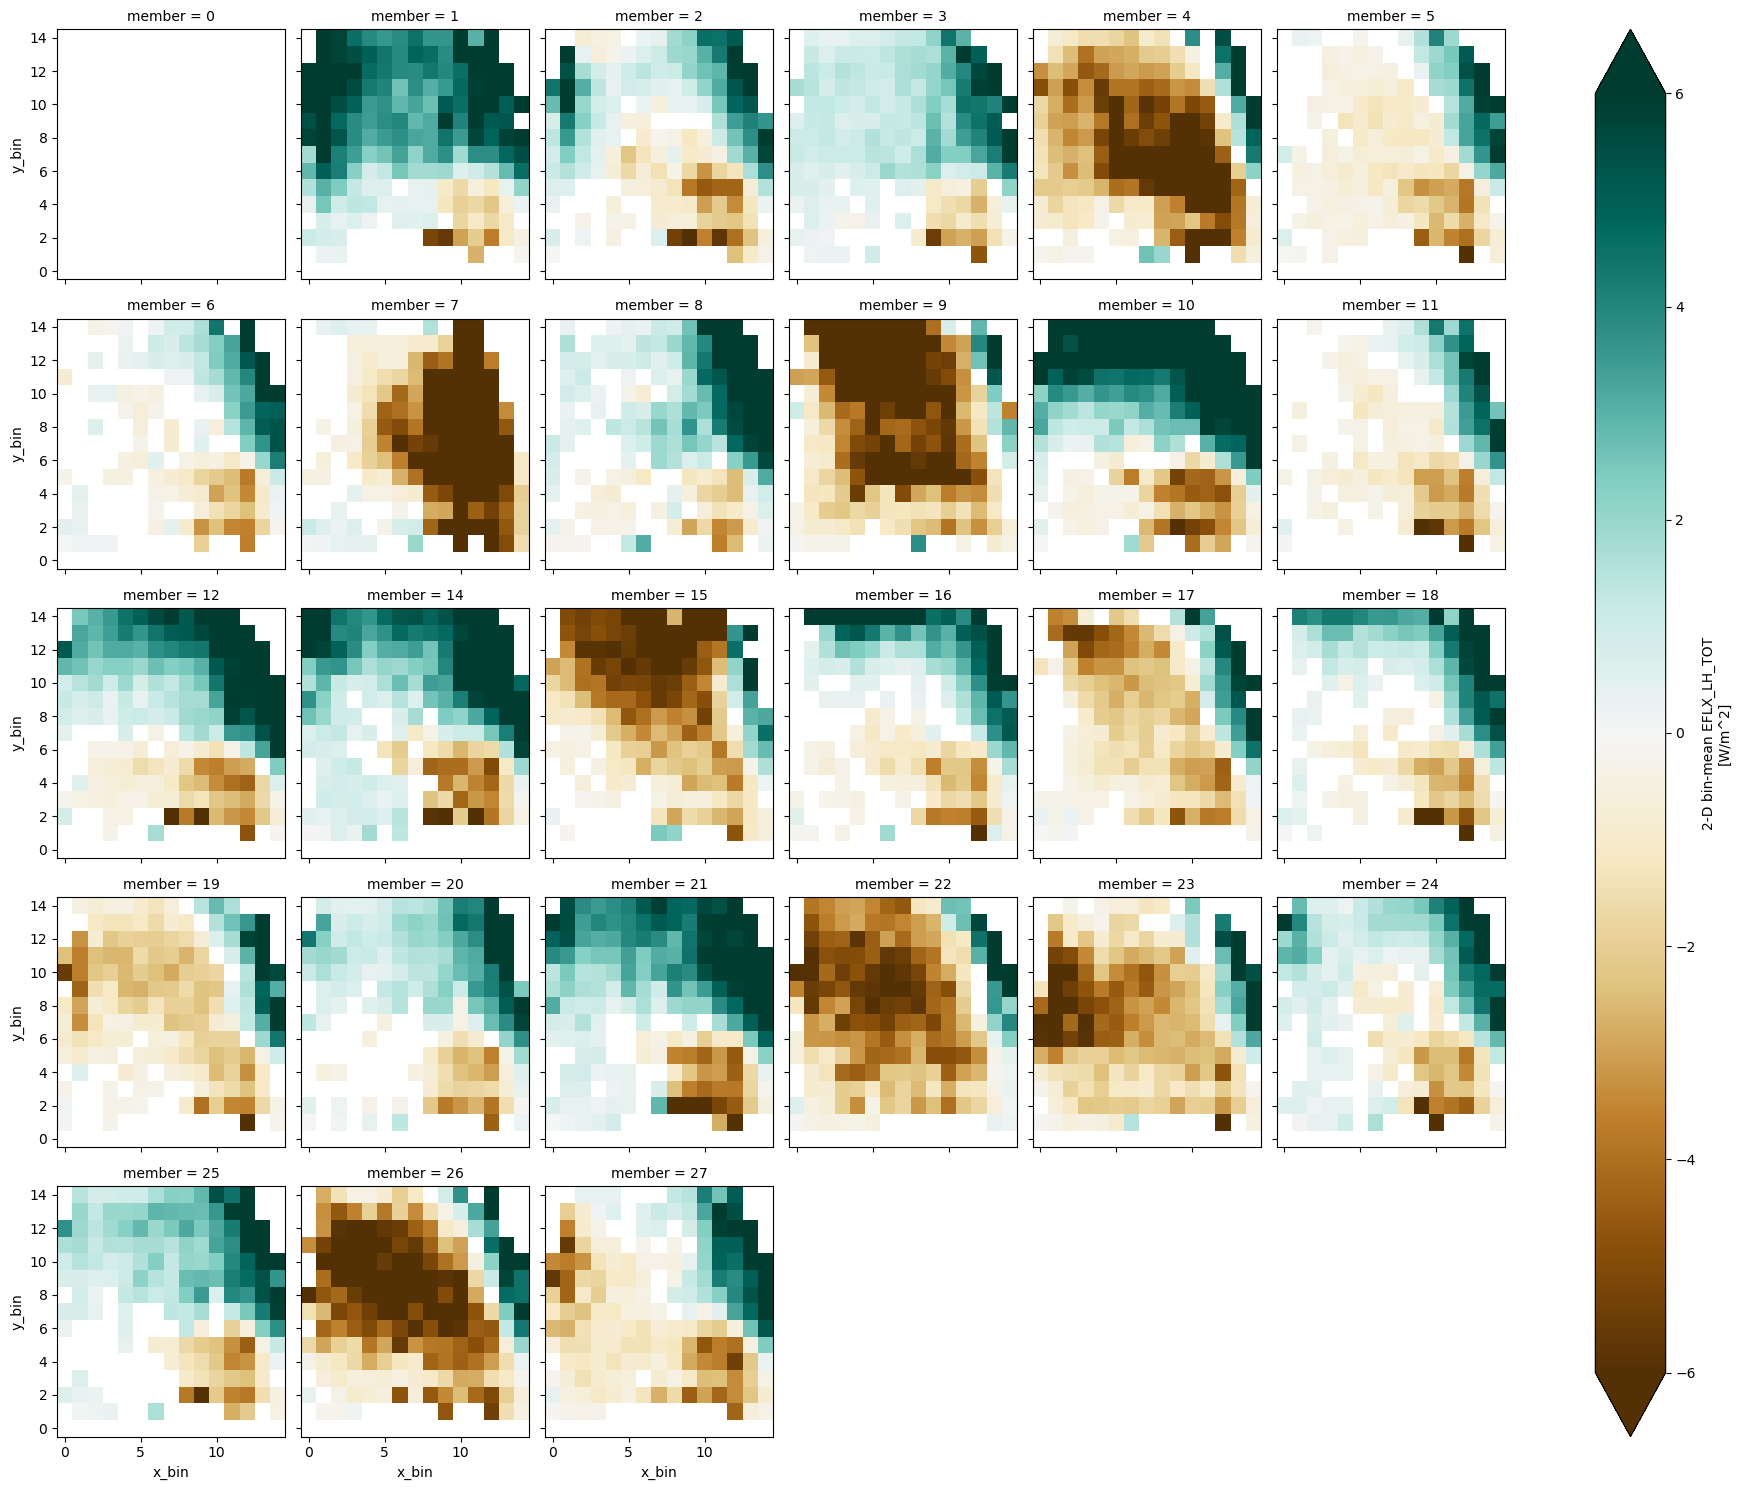

In [183]:
bin_stats.sel(stats='mean').where(significant).plot(col='member', col_wrap=6, vmin=-6, vmax=6, cmap='BrBG', extend='both')


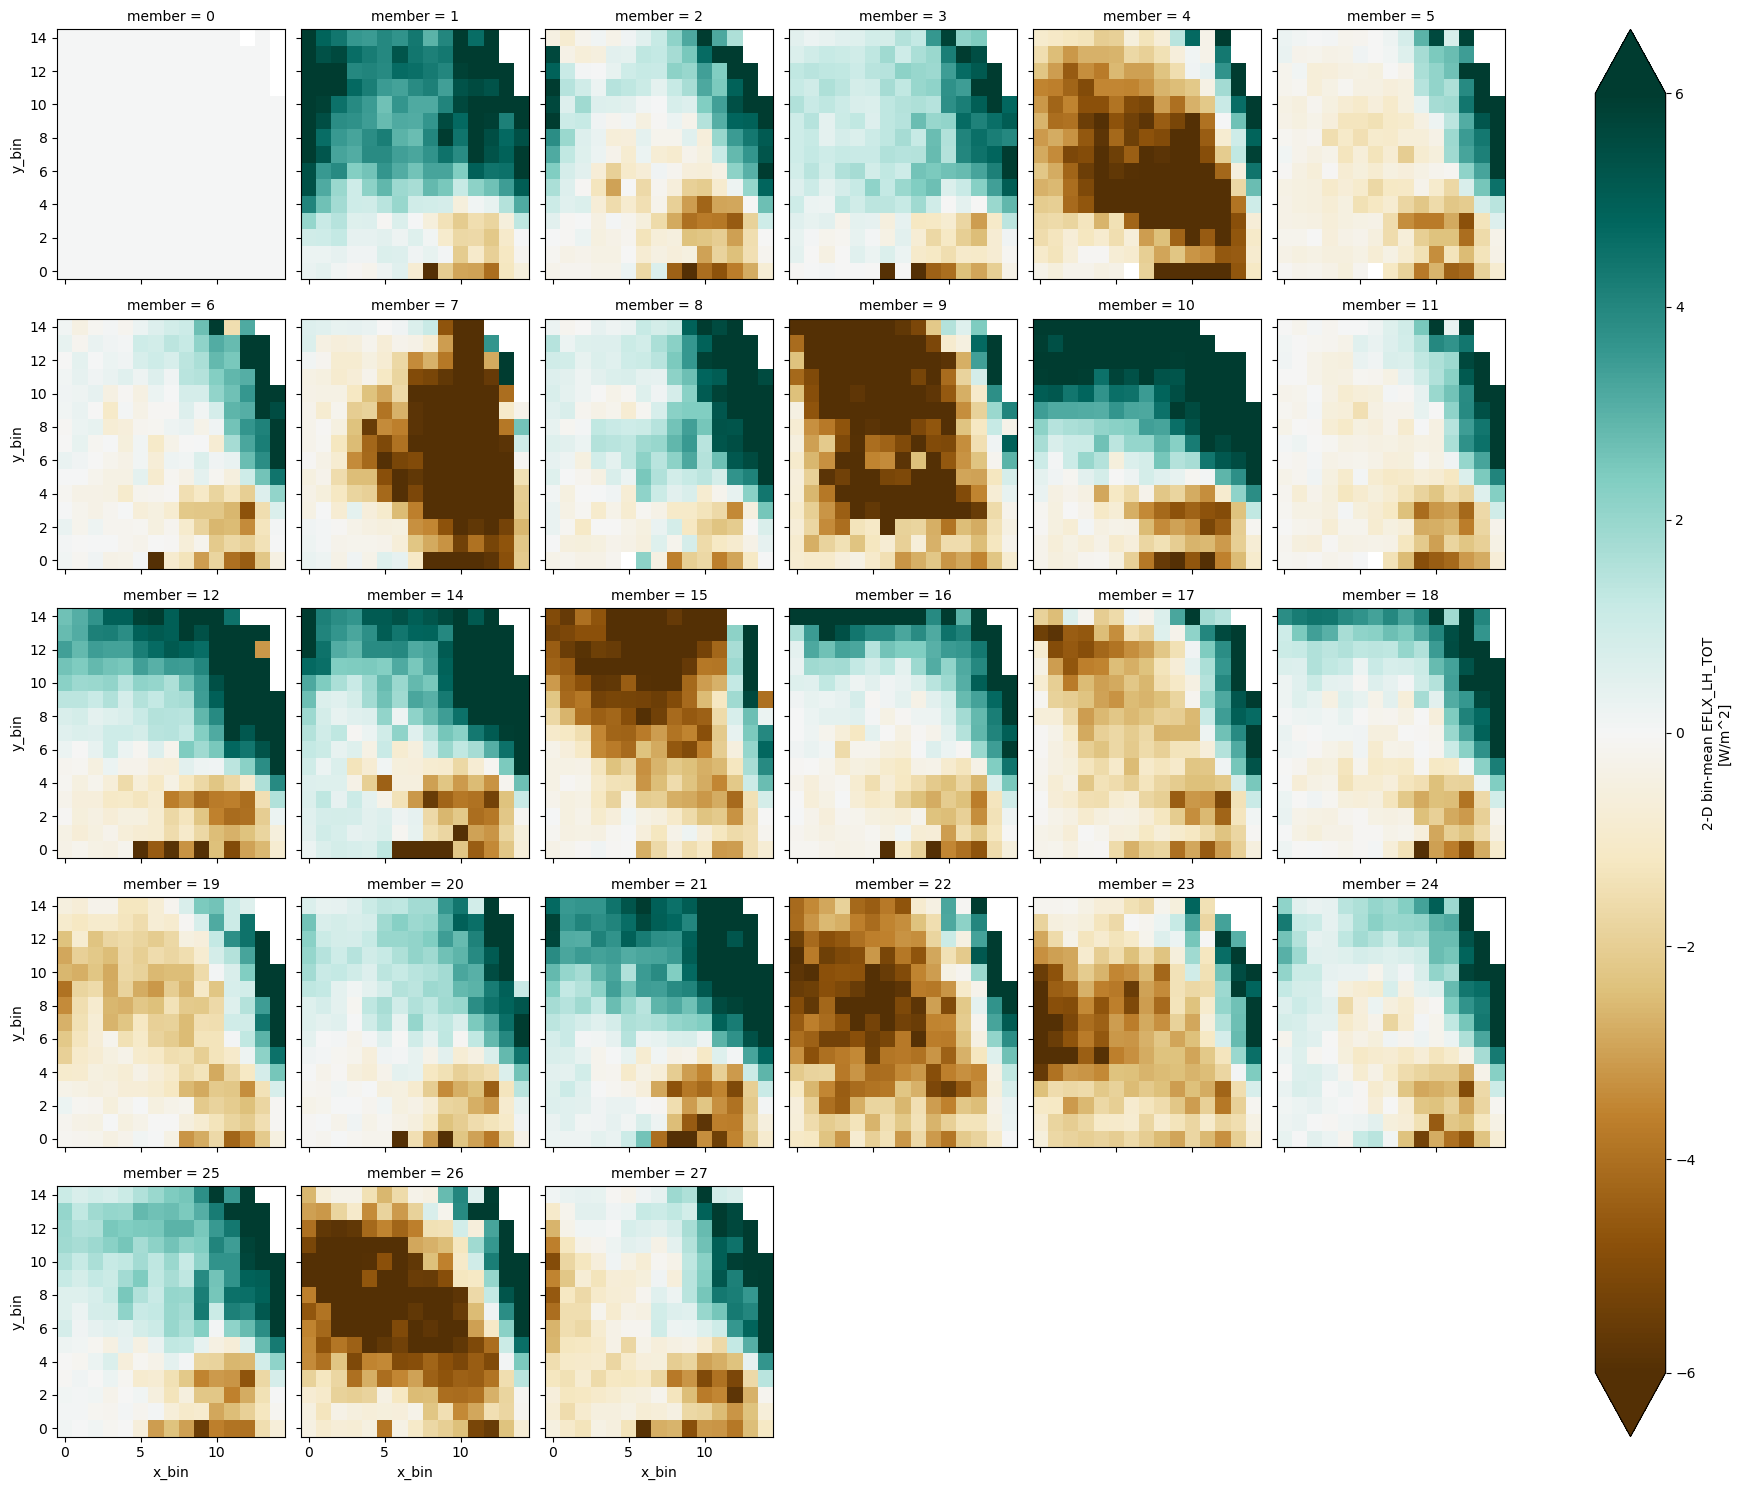

In [ ]:
bin_stats_lai_gr_0.sel(stats='mean').plot(col='member', col_wrap=6, vmin=-6, vmax=6, cmap='BrBG', extend='both')